# Joint Recurrence Plots Analysis - Generalized Synchronization

## Samuel Jaramillo

### Research question
1. Compare the recurrence plot methods for detecting phase, generalised, and complete synchronisation (lag synchronisation is included).

2. Prepare an overview of the ability of the measures derived from cross- and joint recurrence plots and from tau-recurrence rate.

3. (Bonus) improve the tau-recurrence rate measure (CPR).

In [1]:
import numpy as np
import pandas as pd
import recurrence as rec
import matplotlib.pyplot as plt
import string

from scipy.integrate import solve_ivp
from scipy.spatial.distance import pdist, squareform, cdist

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

In [2]:
#Import models
nosynch1 = pd.read_csv('timeseries/GS_nosynch1.csv').to_numpy()

nosynch2 = pd.read_csv('timeseries/GS_nosynch2.csv').to_numpy()

synch1 = pd.read_csv('timeseries/GS_synch1.csv').to_numpy()

synch2 = pd.read_csv('timeseries/GS_synch2.csv').to_numpy()

In [4]:
#View the individual recurrence plots
#No synch
rec_nosynch1 = RecurrencePlot(nosynch1, recurrence_rate=0.1, metric="euclidean")
rm_nosynch1 = rec_nosynch1.recurrence_matrix()

rec_nosynch2 = RecurrencePlot(nosynch2, recurrence_rate=0.1, metric="euclidean")
rm_nosynch2 = rec_nosynch2.recurrence_matrix()

#Synch
rec_synch1 = RecurrencePlot(synch1, recurrence_rate=0.1, metric="euclidean")
rm_synch1 = rec_synch1.recurrence_matrix()

rec_synch2 = RecurrencePlot(synch2, recurrence_rate=0.1, metric="euclidean")
rm_synch2 = rec_synch2.recurrence_matrix()

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


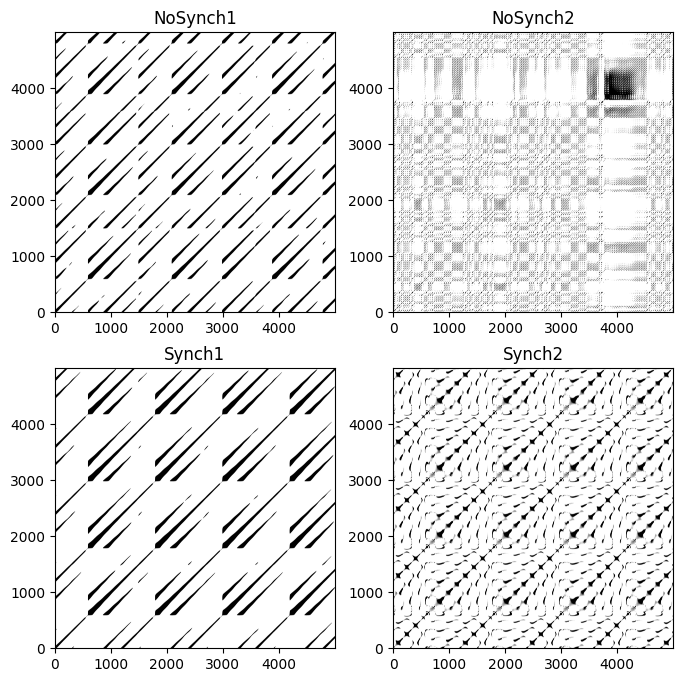

In [30]:
#Visualize
fig, axs = plt.subplots(2,2,figsize=(8, 8))

#Plot
RP_comparison_list = [rm_nosynch1, rm_nosynch2, rm_synch1, rm_synch2]
RP_comparison_titles = ['NoSynch1', 'NoSynch2', 'Synch1', 'Synch2']

l = 0
for i in range(2):
    for j in range(2):
        axs[i][j].imshow(RP_comparison_list[l], origin='lower', cmap = 'binary')
        axs[i][j].set_title(RP_comparison_titles[l])

        l += 1

plt.show()

In [31]:
#Compute JRPs
#No synch
LS_JR_nosynch = JointRecurrencePlot(nosynch1, nosynch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_nosynch = LS_JR_nosynch.recurrence_matrix()

#Synch
LS_JR_synch = JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"))

RMat_LS_synch = LS_JR_synch.recurrence_matrix()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


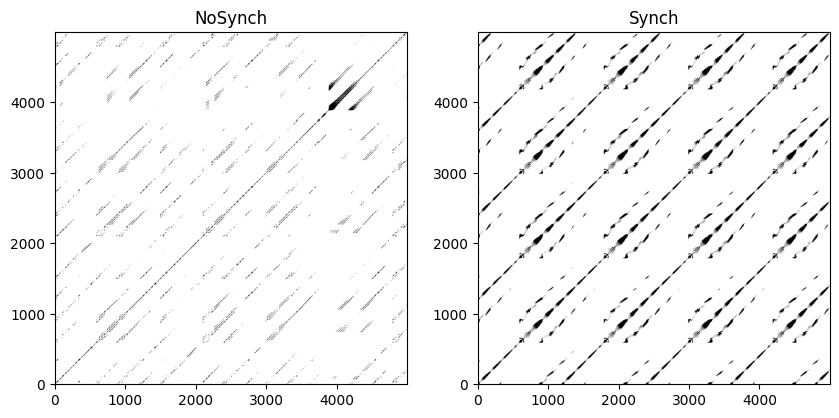

In [32]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(10, 10))

#Plot
axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title('NoSynch')

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title('Synch')


plt.show()

In [33]:
lagged_JR_synch = [JointRecurrencePlot(synch1, synch2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = i) for i in range(100)]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

In [34]:
s_tau_synch = [lagged_JR_synch[i].recurrence_rate()/0.1 for i in range(len(lagged_JR_synch))]

In [35]:
max_lag = np.where(np.array(s_tau_synch) == max(s_tau_synch))[0][0]

max_JRP_tau = lagged_JR_synch[max_lag]

RMat_max_JRP_tau  = max_JRP_tau.recurrence_matrix()

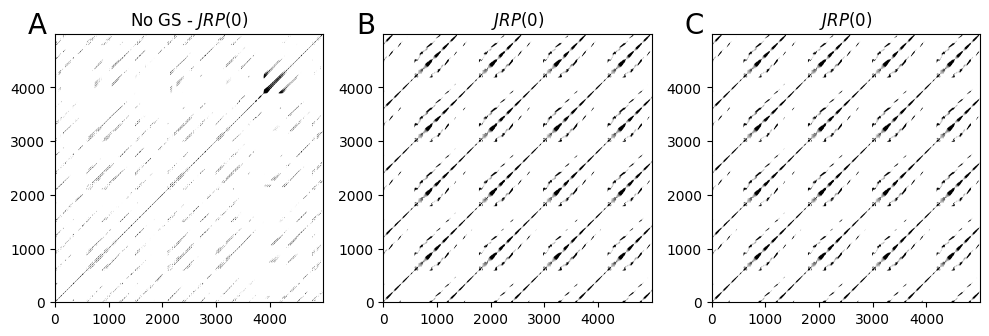

In [ ]:
#Visualize
fig, axs = plt.subplots(1,3,figsize=(10, 4))

axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title(r'No GS - $JRP(0)$')
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title(r'$JRP(0)$')
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)

axs[2].imshow(RMat_max_JRP_tau, origin='lower', cmap = 'binary')
axs[2].set_title(r'$JRP({})$'.format(max_lag))
axs[2].text(-0.1, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=20)


plt.tight_layout()

plt.show()
fig.savefig('plots/JRPs_GS.pdf', dpi=300)

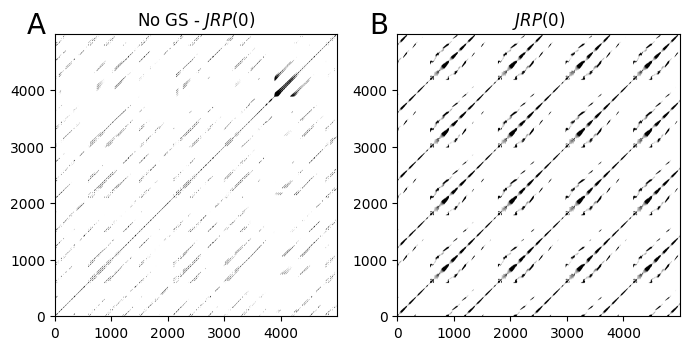

In [ ]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(7, 4))

axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title(r'No GS - $JRP(0)$')
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title(r'$JRP(0)$')
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)


plt.tight_layout()

plt.show()
fig.savefig('plots/JRPs_GS2.pdf', dpi=300)

Makes sense, because there's no lag. 

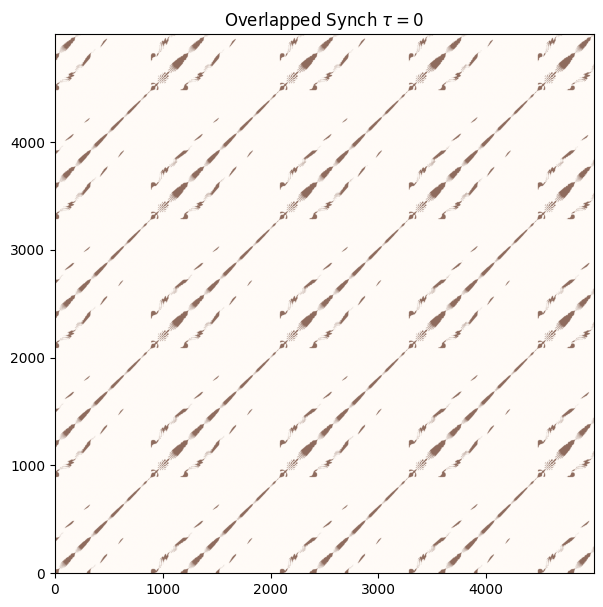

In [21]:
#Visualize
fig, axs = plt.subplots(figsize=(7, 7))

axs.imshow(RMat_LS_synch, origin='lower', cmap = 'binary', alpha = 0.4)

axs.imshow(RMat_max_JRP_tau, origin='lower', cmap = 'Oranges', alpha = 0.4)
axs.set_title(r'Overlapped Synch $\tau = {}$'.format(max_lag))


plt.show()

#### $S(\tau)$ analysis

In [38]:
print('S(0) NoSynch', LS_JR_nosynch.recurrence_rate()/0.1)
print('S(0) Synch', LS_JR_synch.recurrence_rate()/0.1)

S(0) NoSynch 0.1372728
S(0) Synch 0.45367759999999996


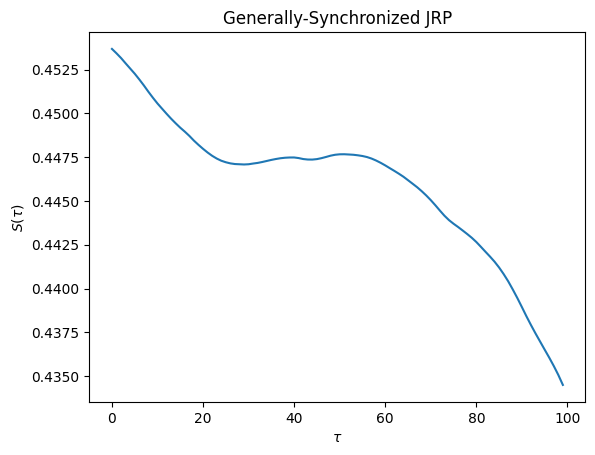

In [ ]:
fig, axs = plt.subplots()

#Plot
axs.plot(s_tau_synch)
axs.set_xlabel(r'$\tau$')
axs.set_ylabel(r'$S(\tau)$')
axs.set_title(r'Generally-Synchronized JRP')

plt.show()

fig.savefig('plots/GS_S_tau.pdf', dpi=300)

Evaluation of sensitivity of $S(\tau)$ to coupling

In [23]:
def coupled_system(t, state, driver="roessler", response="lorenz", 
                   a=0.2, b=0.2, c=5.7,
                   sigma=10, rho=28, beta=8/3, eps=0.1,
                   synch=["x", "y", "z"],
                   g=None):
    '''
    g : Functional Relationship between driver and response system (python function)
    '''

    if g is None:
          def g(x):
                return x

    x1, y1, z1, x2, y2, z2 = state

    if driver == "roessler":
        dx1 = -(y1 + z1)
        dy1 = x1 + a * y1
        dz1 = b + (x1 - c) * z1

        if response == "lorenz":
                dx2 = sigma * (y2 - x2) + eps * g(x1) if "x" in synch else sigma * (y2 - x2) 
                dy2 = x2 * (rho - z2) - y2 + eps * g(y1) if "y" in synch else x2 * (rho - z2) - y2
                dz2 = x2 * y2 - beta * z2 + eps * g(z1) if "z" in synch else x2 * y2 - beta * z2
        elif response == "roessler":
                dx2 = -(y2 + z2) + eps * g(x1) if "x" in synch else -(y2 + z2)
                dy2 = x2 + a * y2 + eps * g(y1) if "y" in synch else x2 + a * y2
                dz2 = b + (x2 - c) * z2 + eps * g(z1) if "z" in synch else b + (x2 - c) * z2
    
    elif driver == "lorenz":
        dx1 = sigma * (y1 - x1)
        dy1 = x1 * (rho - z1) - y1
        dz1 = x1 * y1 - beta * z1

        if response == "lorenz":
                dx2 = sigma * (y2 - x2) + eps * g(x1) if "x" in synch else sigma * (y2 - x2)
                dy2 = x2 * (rho - z2) - y2 + eps * g(y1) if "y" in synch else x2 * (rho - z2) - y2
                dz2 = x2 * y2 - beta * z2 + eps * g(z1) if "z" in synch else x2 * y2 - beta * z2
        elif response == "roessler":
                dx2 = -(y2 + z2) + eps * g(x1) if "x" in synch else -(y2 + z2)
                dy2 = x2 + a * y2 + eps * g(y1) if "y" in synch else x2 + a * y2
                dz2 = b + (x2 - c) * z2 + eps * g(z1) if "z" in synch else b + (x2 - c) * z2


    return [dx1, dy1, dz1, dx2, dy2, dz2]

In [24]:
T = 12000 * 0.02
dt = 0.02

XYZ0 = np.random.rand(6)   

t_span = (0, T)
t_eval = np.arange(0, T, dt)

a, b, c = 0.16, 0.1, 8.5        # Roessler
sigma, rho, beta = 10, 28, 8/3 # Lorenz

driver = "roessler"
response = "lorenz"

synch = ["x"] 

def g(x):
      #return np.tanh(x)
      return x

In [42]:
'''
#### Integration ####
from tqdm import tqdm

epss = np.linspace(0,150,50)
#epss = np.arange(0, 150, 3) 

results = {}

for e in tqdm(epss):
    results[e] = solve_ivp(
        coupled_system,
        t_span,
        XYZ0,
        t_eval=t_eval,
        args=(driver, response, a, b, c, sigma, rho, beta, e, synch, g),
        method="RK45"
    )
'''

'\n#### Integration ####\nfrom tqdm import tqdm\n\nepss = np.linspace(0,150,50)\n#epss = np.arange(0, 150, 3) \n\nresults = {}\n\nfor e in tqdm(epss):\n    results[e] = solve_ivp(\n        coupled_system,\n        t_span,\n        XYZ0,\n        t_eval=t_eval,\n        args=(driver, response, a, b, c, sigma, rho, beta, e, synch, g),\n        method="RK45"\n    )\n'

In [43]:

'''
JPR_list = []

for e in epss:
    sol_c = results[e]

    sol1 = sol_c.y[0:3, 7000:].T
    sol2 = sol_c.y[3:6, 7000:].T

    lagged_JR_synch_i = [JointRecurrencePlot(sol1, sol2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in range(30)]
    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])


    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)

    JPR_list.append(JPR_i)
'''

'\nJPR_list = []\n\nfor e in epss:\n    sol_c = results[e]\n\n    sol1 = sol_c.y[0:3, 7000:].T\n    sol2 = sol_c.y[3:6, 7000:].T\n\n    lagged_JR_synch_i = [JointRecurrencePlot(sol1, sol2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in range(30)]\n    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])\n\n\n    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)\n\n    JPR_list.append(JPR_i)\n'

In [44]:
'''
fig, axs = plt.subplots()

#Plot

axs.plot(epss,JPR_list)
axs.set_xscale("log")
axs.set_xlabel(r"$\mu$")
axs.set_title(r'JPR PhaseSynch')

plt.show()
'''

'\nfig, axs = plt.subplots()\n\n#Plot\n\naxs.plot(epss,JPR_list)\naxs.set_xscale("log")\naxs.set_xlabel(r"$\\mu$")\naxs.set_title(r\'JPR PhaseSynch\')\n\nplt.show()\n'

In [25]:
#### Integration ####
from tqdm import tqdm

epss = np.linspace(0,150,50)
#epss = np.arange(0, 150, 3) 

results = {}

for e in tqdm(epss):
    results[e] = solve_ivp(
        coupled_system,
        t_span,
        XYZ0,
        t_eval=t_eval,
        args=(driver, response, a, b, c, sigma, rho, beta, e, synch, g),
        method="RK45"
    )

100%|██████████| 50/50 [00:28<00:00,  1.76it/s]


In [46]:
JPR_list = []

for e in tqdm(epss):
    sol_c = results[e]

    sol1 = sol_c.y[0:3, 7000:].T
    sol2 = sol_c.y[3:6, 7000:].T

    #We already know the max is when lag is 0
    #lagged_JR_synch_i = [JointRecurrencePlot(sol1, sol2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in range(30)]
    lagged_JR_synch_i = [JointRecurrencePlot(sol1, sol2, recurrence_rate=(0.1,0.1), metric=("euclidean","euclidean"), lag = j) for j in range(5)]
    s_tau_synch_i = np.array([lagged_JR_synch_i[k].recurrence_rate()/0.1 for k in range(len(lagged_JR_synch_i))])


    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)

    JPR_list.append(JPR_i)

  0%|          | 0/50 [00:00<?, ?it/s]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

  2%|▏         | 1/50 [00:20<17:04, 20.90s/it]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

  4%|▍         | 2/50 [00:41<16:38, 20.81s/it]

...

 96%|█████████▌| 48/50 [16:17<00:40, 20.25s/it]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

 98%|█████████▊| 49/50 [16:37<00:20, 20.22s/it]

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...
Calculating 

100%|██████████| 50/50 [16:57<00:00, 20.35s/it]


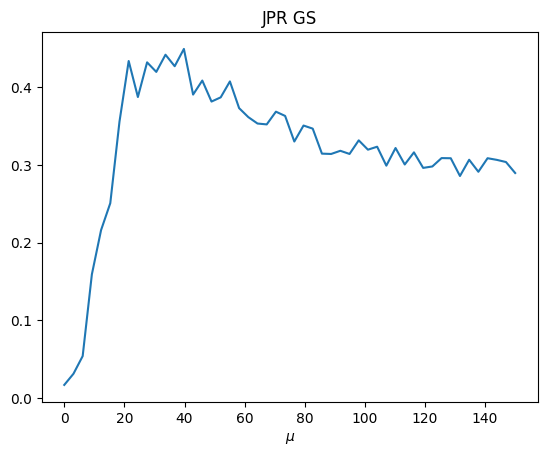

<Figure size 640x480 with 0 Axes>

In [51]:
fig, axs = plt.subplots()

#Plot

axs.plot(epss,JPR_list)
axs.set_xlabel(r"$\mu$")
axs.set_title(r'JPR GS')

plt.show()
plt.savefig('JPR_GS.png')

In [55]:
#Save to avoid computing it again
JPR_list_saved = pd.DataFrame(JPR_list)

# save the dataframe as a csv file
JPR_list_saved.to_csv("GS_JPR_list.csv", index=False)

In [56]:
CPR_list = []

for e in tqdm(epss):
    sol_c = results[e]

    sol1 = sol_c.y[0:3, 7000:].T
    sol2 = sol_c.y[3:6, 7000:].T

    rp_drive = RecurrencePlot(sol1, metric="euclidean", recurrence_rate=0.1)
    rp_response = RecurrencePlot(sol2, metric="euclidean", recurrence_rate=0.1)

    RP_drive = rp_drive.recurrence_matrix()
    RP_response = rp_response.recurrence_matrix()

    C = rec.cpr(RP_drive, RP_response)

    CPR_list.append(C)

  0%|          | 0/50 [00:00<?, ?it/s]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  2%|▏         | 1/50 [00:04<03:23,  4.15s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


  4%|▍         | 2/50 [00:08<03:19,  4.15s/it]

...

 96%|█████████▌| 48/50 [03:20<00:08,  4.16s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


 98%|█████████▊| 49/50 [03:24<00:04,  4.15s/it]

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


100%|██████████| 50/50 [03:28<00:00,  4.17s/it]


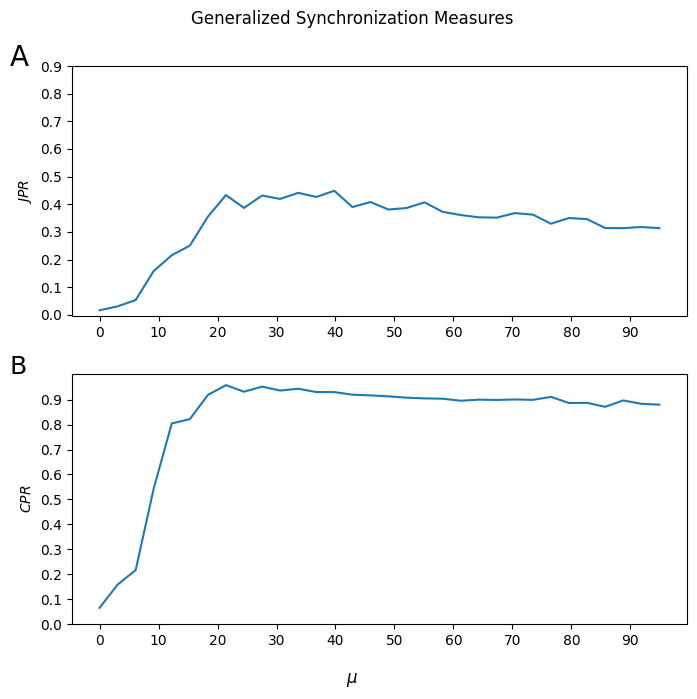

In [ ]:
fig, axs = plt.subplots(2,1,figsize=(7, 7))

#JPR
axs[0].plot(epss[:-18],JPR_list[:-18])
axs[0].set_yticks(np.arange(0,1,0.1))
axs[0].set_xticks(np.arange(0,100,10))
axs[0].set_ylabel(r"$JPR$")
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)


#CPR
axs[1].plot(epss[:-18],CPR_list[:-18])
axs[1].set_yticks(np.arange(0,1,0.1))
axs[1].set_xticks(np.arange(0,100,10))
axs[1].set_ylabel(r"$CPR$")
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=18)

fig.suptitle('Generalized Synchronization Measures')
fig.supxlabel(r"$\mu$")

plt.tight_layout()
plt.show()


fig.savefig('plots/GS_JPRandCPR..pdf', dpi=300)

## Use FNN?

In [3]:
#Recurrence matrix updated version
def recurrence_matrix_fan(timeseries, RR, transpose = False):
    nn_i = int(RR*len(timeseries))

    if timeseries.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                current_row.append(current_value)

            current_row = np.array(current_row)
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))

        for i in range(d_matrix.shape[0]):
            current_row = d_matrix[i]
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1

            d_matrix[i] = current_row   

        return d_matrix 

In [6]:
#View the individual recurrence plots
#No synch
rm_nosynch1 = recurrence_matrix_fan(nosynch1, RR = 0.1)

rm_nosynch2 = recurrence_matrix_fan(nosynch2, RR = 0.1)

#Synch
rm_synch1 = recurrence_matrix_fan(synch1, RR = 0.1)

rm_synch2 = recurrence_matrix_fan(synch2, RR = 0.1)


In [7]:
print(rec.cpr(rm_synch1, rm_synch2))
print(rec.cpr(rm_nosynch1, rm_nosynch2))

0.8581640918896385
0.15214144762606124


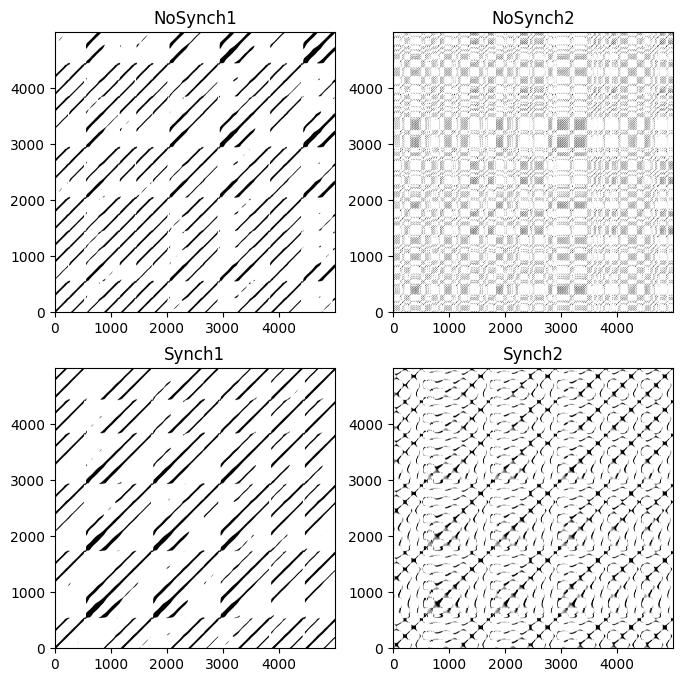

In [8]:
#Visualize
fig, axs = plt.subplots(2,2,figsize=(8, 8))

#Plot
RP_comparison_list = [rm_nosynch1, rm_nosynch2, rm_synch1, rm_synch2]
RP_comparison_titles = ['NoSynch1', 'NoSynch2', 'Synch1', 'Synch2']

l = 0
for i in range(2):
    for j in range(2):
        axs[i][j].imshow(RP_comparison_list[l], origin='lower', cmap = 'binary')
        axs[i][j].set_title(RP_comparison_titles[l])

        l += 1

plt.show()

In [9]:
#Compute JRPs
#No synch
RMat_LS_nosynch = rm_nosynch1*rm_nosynch2

#Synch
RMat_LS_synch = rm_synch1*rm_synch2

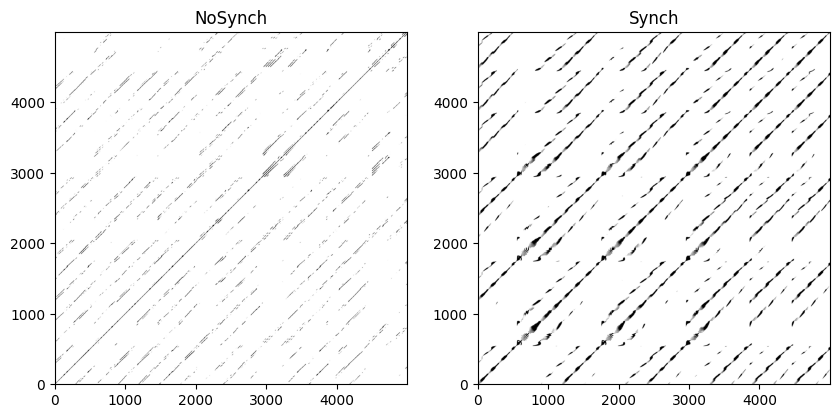

In [10]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(10, 10))

#Plot
axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title('NoSynch')

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title('Synch')


plt.show()

In [11]:
lagged_time_series_y = [synch2[i:len(synch1)-100+i] for i in range(100)]

In [12]:
rec_x = recurrence_matrix_fan(synch1[:-100], RR=0.1)

In [13]:
s_tau_synch = []

for i in range(100):
    actual_y = lagged_time_series_y[i]
    

    rec_y = recurrence_matrix_fan(actual_y, RR=0.1)

    jrp = rec_x*rec_y

    N = len(actual_y)


    s_tau_synch.append((np.sum(jrp)/(N**2))/0.1)

In [14]:
max_lag = np.where(np.array(s_tau_synch) == max(s_tau_synch))[0][0]

max_JRP_tau = lagged_time_series_y[max_lag]

RMat_max_JRP_tau  = recurrence_matrix_fan(max_JRP_tau,RR=0.1)

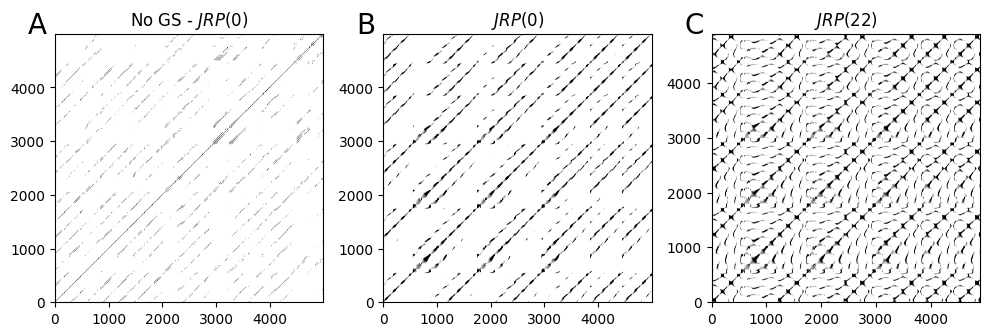

In [15]:
#Visualize
fig, axs = plt.subplots(1,3,figsize=(10, 4))

axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title(r'No GS - $JRP(0)$')
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title(r'$JRP(0)$')
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)

axs[2].imshow(RMat_max_JRP_tau, origin='lower', cmap = 'binary')
axs[2].set_title(r'$JRP({})$'.format(max_lag))
axs[2].text(-0.1, 1, string.ascii_uppercase[2], transform=axs[2].transAxes, 
            size=20)


plt.tight_layout()

plt.show()
fig.savefig('plots/JRPs_GSFNN.pdf', dpi=300)

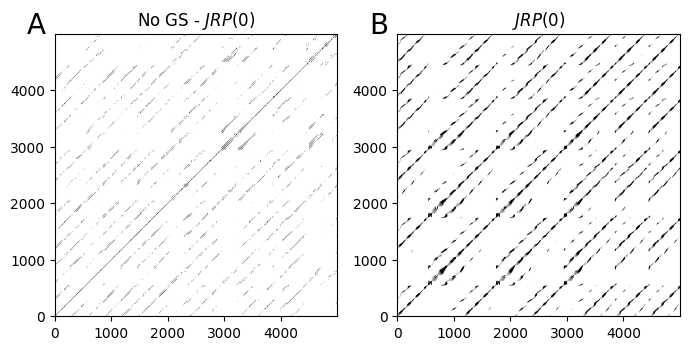

In [16]:
#Visualize
fig, axs = plt.subplots(1,2,figsize=(7, 4))

axs[0].imshow(RMat_LS_nosynch, origin='lower', cmap = 'binary')
axs[0].set_title(r'No GS - $JRP(0)$')
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

axs[1].imshow(RMat_LS_synch, origin='lower', cmap = 'binary')
axs[1].set_title(r'$JRP(0)$')
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)


plt.tight_layout()

plt.show()
fig.savefig('plots/JRPs_GS2FNN.pdf', dpi=300)

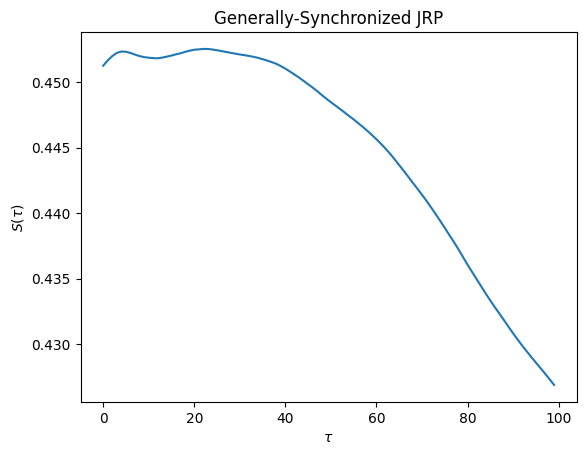

In [17]:
fig, axs = plt.subplots()

#Plot
axs.plot(s_tau_synch)
axs.set_xlabel(r'$\tau$')
axs.set_ylabel(r'$S(\tau)$')
axs.set_title(r'Generally-Synchronized JRP')

plt.show()

fig.savefig('plots/GS_S_tauFNN.pdf', dpi=300)

Could be due to correlation time and Theiler window. Notice that values are small. Would still keep somewhat original plot. 

In [18]:
from scipy import stats


pearson_tau = []

for i in range(100):
    actual_y = lagged_time_series_y[i].T[1]
    

    x = synch1[:-100]

    pearson_tau.append(stats.pearsonr(x.T[1], actual_y).statistic)


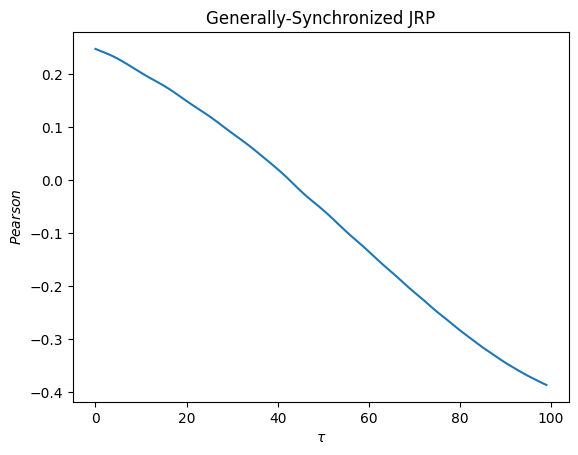

In [19]:
fig, axs = plt.subplots()

#Plot
axs.plot(pearson_tau)
axs.set_xlabel(r'$\tau$')
axs.set_ylabel(r'$Pearson$')
axs.set_title(r'Generally-Synchronized JRP')

plt.show()

In [20]:
from tqdm import tqdm

In [26]:
JPR_list = []

for e in tqdm(epss):
    sol_c = results[e]

    sol1 = sol_c.y[0:3, 7000:].T
    sol2 = sol_c.y[3:6, 7000:].T

    ref = recurrence_matrix_fan(sol1[:-100],RR=0.1)

    lagged_JR_synch_i = [ref*recurrence_matrix_fan(sol2[j:len(sol2)-100+j],RR=0.1) for j in range(40)]
    
    s_tau_synch_i = np.array([(np.sum(lagged_JR_synch_i[k])/(len(sol1[:-100])**2))/0.1 for k in range(len(lagged_JR_synch_i))])


    JPR_i = (np.max(s_tau_synch_i) - 0.1)/(1 - 0.1)

    JPR_list.append(JPR_i)

100%|██████████| 50/50 [36:37<00:00, 43.96s/it]


In [27]:
#Save to avoid computing it again
JPR_list_saved = pd.DataFrame(JPR_list)

# save the dataframe as a csv file
JPR_list_saved.to_csv("GS_JPR_listFAN.csv", index=False)

In [28]:
CPR_list = []

for e in tqdm(epss):
    sol_c = results[e]

    sol1 = sol_c.y[0:3, 7000:].T
    sol2 = sol_c.y[3:6, 7000:].T

    RP_drive = recurrence_matrix_fan(sol1,RR=0.1)
    RP_response = recurrence_matrix_fan(sol2,RR=0.1)

    C = rec.cpr(RP_drive, RP_response)

    CPR_list.append(C)

100%|██████████| 50/50 [01:39<00:00,  1.99s/it]


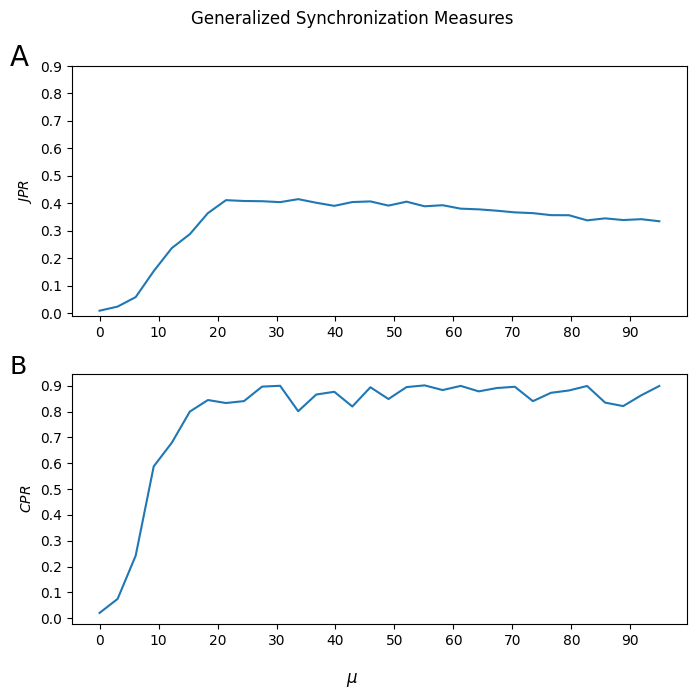

In [29]:
fig, axs = plt.subplots(2,1,figsize=(7, 7))

#JPR
axs[0].plot(epss[:-18],JPR_list[:-18])
axs[0].set_yticks(np.arange(0,1,0.1))
axs[0].set_xticks(np.arange(0,100,10))
axs[0].set_ylabel(r"$JPR$")
axs[0].text(-0.1, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)


#CPR
axs[1].plot(epss[:-18],CPR_list[:-18])
axs[1].set_yticks(np.arange(0,1,0.1))
axs[1].set_xticks(np.arange(0,100,10))
axs[1].set_ylabel(r"$CPR$")
axs[1].text(-0.1, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=18)

fig.suptitle('Generalized Synchronization Measures')
fig.supxlabel(r"$\mu$")

plt.tight_layout()
plt.show()


fig.savefig('plots/GS_JPRandCPRFAN.pdf', dpi=300)